# LibriSpeech ASR dataset builder

Builds a single-sentence subset from [openslr/librispeech_asr](https://huggingface.co/datasets/openslr/librispeech_asr) (`clean` splits) with **recorded** LibriSpeech audio—not TTS. Output goes to `data/librispeech_asr/` for upload to [Pawlo77/mllm-shap](https://huggingface.co/datasets/Pawlo77/mllm-shap) as config **`single_sentence__librispeech_asr`**.

## Purpose

Produces quality-filtered English prompts with `audio__original` and durations as `list[bytes]` / `list[float]`. Uses a RAM-efficient two-pass flow—load and filter text first, attach audio only for the final prompt set.

This notebook:

1. Loads LibriSpeech ASR text from `clean` splits (`train.100`, `train.360`, `test`) with a pinned revision.
2. Filters to single-sentence English prompts and deduplicates by transcript.
3. Applies NLP interestingness filtering, token-count limits, and stratified sampling toward `HUB_TARGET_SAMPLES`.
4. Attaches `audio__original` from parquet shards for sampled prompts only.
5. Saves `single_sentence__librispeech_asr.parquet` and a JSON text sample.

**Published size (last run):** **609** rows — below `HUB_TARGET_SAMPLES` (1000) because only 609 prompts pass `token_count ≤ 12` after NLP filtering; stratified sampling cannot exceed that pool.

Run when rebuilding the LibriSpeech-derived Hub config; spot-check with `overview.ipynb` after upload.

## Preprocessing pipeline

Row counts are from the last full notebook run; your numbers may differ slightly if upstream data or filters change.

```mermaid
flowchart TD
  subgraph load["Text-first load"]
    A["openslr/librispeech_asr<br/>clean: train.100 · train.360 · test"]
    B["load_librispeech_text_pool<br/>135,173 rows"]
    C["sentence columns · English<br/>135,117 unique prompts"]
    D["dedupe_by_prompt"]
    A --> B --> C --> D
  end

  subgraph single["single_sentence__librispeech_asr"]
    E["single-sentence entries<br/>135,117"]
    F["run_nlp_quality_filter<br/>rule 134,160 → interesting 107,328 → dedup 31,223"]
    G["token_count ≤ 12<br/>609"]
    H["sample_single_sentence_nk<br/>target 1,000 → 609"]
    I["attach_librispeech_audio<br/>609 / 609"]
    J["save_dataset_and_sample<br/>single_sentence__librispeech_asr.parquet<br/>609 rows"]
    D --> E --> F --> G --> H --> I --> J
  end

  subgraph hub["Hub"]
    K["upload_to_hub / Makefile<br/>Pawlo77/mllm-shap"]
    J --> K
  end
```


# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
from src.setup import configure_notebook_environment

configure_notebook_environment(set_plot_style=True)

PosixPath('/Users/pawelp/Desktop/education/pw/bachelor/MLLM-Shap')

In [3]:
import shutil
from pprint import pprint

import pandas as pd

from src import (
    add_english_flag,
    add_sentence_columns,
    attach_librispeech_audio,
    compute_budgets,
    dedupe_by_prompt,
    get_device,
    get_token_model,
    load_librispeech_text_pool,
    plot_interestingness_distribution,
    plot_token_count_comparison,
    prepare_candidates,
    print_datasets_list_length_counts,
    report_dataset_stats,
    run_nlp_quality_filter,
    run_token_count_filter,
    sample_single_sentence_nk,
    save_single_sentence,
)
from src.constants import (
    HUB_TARGET_SAMPLES,
    LIBRISPEECH_ASR__CONFIG,
    SINGLE_SENTENCE__LIBRISPEECH_ASR,
)
from src.languages import LanguageClassifier

device = get_device()
print(f"Using device: {device}")

language_classifier = LanguageClassifier()
model_for_tokens = get_token_model(device)

Using device: mps


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

W0522 21:28:48.613000 9857 torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


# Text dataset preparation and EDA

## Preprocessing

### Dataset preparation

Use RAM-optimized text-first loading from LibriSpeech ASR (`clean`) on splits `train.100`, `train.360`, and `test` (see pipeline diagram in the intro). Audio is attached only after final sampling, then normalized to `audio__original` as `list[bytes]` with `audio__original__duration` as `list[float]`.

In [4]:
df = load_librispeech_text_pool(LIBRISPEECH_ASR__CONFIG)

Loader: clean_multi_split_text_first_v5
Available clean split dirs: ['test', 'train.100', 'train.360', 'validation']
Skipping missing split: dev (candidates: ('dev', 'dev.clean'))
Resolved splits: ['train.100', 'train.360', 'test']
Loading text-only pool from clean/train.100/ (14 shards)


I0522 21:28:57.452815 3929120 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


Loading text-only pool from clean/train.360/ (48 shards)


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/47 [00:00<?, ?it/s]

Loading text-only pool from clean/test/ (1 shards)
Text pool rows loaded: 135173


Split prompt into sentences and check if they are English.

In [5]:
df = add_sentence_columns(df)
df = add_english_flag(df, language_classifier)
report_dataset_stats(df, include_audio=False, show_budgets=False)

  0%|          | 0/135173 [00:00<?, ?it/s]

  0%|          | 0/135173 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'avg_characters__num': 182.53,
 'avg_sentences__num': 1.0,
 'characters__num': 24672615,
 'min_sentences__num': 1,
 'rows__num': 135173,
 'total_sentences__num': 135173,
 'unique_entries__num': 135117,
 'unique_entries__pct': 99.96}


,datasets,num_rows,total_characters,avg_num_characters,avg_num_sentences,total_sentences
0,LibriSpeech-ASR-clean,135173,24672615,182.526207,1.0,135173


In [6]:
non_english_entries: pd.Series = df[~df["is_english"]]["prompt"]
pprint(sorted(non_english_entries.unique()))

['A AS IN MAY E AS IN MET U AS IN USE A',
 'A BLAKENEY HAD DIED ON BOSWORTH FIELD',
 'A GREAT BOY WHO IS ALMOST SIX',
 'A GREAT SAINT SAINT FRANCIS XAVIER',
 'A HURON WAR CHIEF NAMED ETIENNE',
 'A LONG PAUSE NURSE ROSEMARY GRAY WAITED',
 'A SPECIES TO BE DESTROYED',
 'A SUBTLE FIRE FLOWED THROUGH MY VEINS',
 'A WASTE A WASTE A WASTE MY TWEMLOW',
 'ABEMY REPLICA',
 'ABUSE NOT BY WORD HIM WHOM THOU HAST TO PUNISH IN DEED',
 'AGAIN AGAIN',
 'ALAMEDA ANTOINETTE MONOPLANE PERIQUE BLERIOT MONOPLANE LOI TONG SANTOS '
 'DUMONT MONOPLANE WENDELL CURTIS BIPLANE DE TROMP FARMAN BIPLANE',
 'ALAS SIGHED SHE',
 'AMONG FRIENDS BUT IT WAS A MISTAKE',
 "AN DE FIRE DIED DOWN AN DE WIND BLEWED MO'NFUL OUTSIDE",
 "AN DE WIMMINS DEY LET OUT A TURR'BLE SCREECH KASE DEY SEED TWA'N'T NUTTIN "
 'BUT A BIG OWL SETTIN DAR BLINKIN',
 'AN ESCAPE HAD BEEN PLANNED',
 "AN I DON'T LIKE SALADS",
 'AN UNUSUAL HONOR',
 'AN WE SAY HOLD ON AS LONGS U KIN',
 'ANGOR PAIN PAINFUL TO HEAR',
 'ANTONIA SEEMED FRIGHTENED AT FIRST

In [7]:
print(pd.Series(non_english_entries).value_counts())
del non_english_entries

prompt
MONDAY                                  2
A GREAT SAINT SAINT FRANCIS XAVIER      2
AS AUGUSTINE SAYS                       2
JULY THIRTIETH EIGHTEEN THIRTY EIGHT    1
RIMER                                   1
                                       ..
DEAR GOOD RENEE                         1
EVEN UNTO BONDS AS AN EVIL DOER         1
DOMESTICK GREATNESS UNATTAINABLE        1
I ANSWERED AS BEST I COULD              1
AY ME                                   1
Name: count, Length: 419, dtype: int64


Deduplicate by prompt. Because LibriSpeech can contain repeated transcripts across splits/speakers,
we collapse duplicates and keep the union of source dataset labels.
For `audio__original` we retain the first occurrence, matching the original single-sentence deduplication strategy.

In [8]:
df = dedupe_by_prompt(df, keep_audio=False)

# Single Sentence Dataset (target 1 000 · last run 609)

A dataset containing single-sentence scenarios with recorded LibriSpeech audio. Audio is attached only after final sampling for RAM efficiency:
`audio__original` (as `list[bytes]`) and `audio__original__duration` (as `list[float]`). No TTS columns.

## Filter to single-sentence entries

In [9]:
single_sentence__df: pd.DataFrame = df[df["sentences__num"] == 1].copy()
print(
    f"Unique single-sentence entries before quality filtering: {len(single_sentence__df)}"
)

Unique single-sentence entries before quality filtering: 135117


In [10]:
single_sentence__df.head(3)

,prompt,datasets,sentences,sentences__num
0,A AS IN MAY E AS IN MET U AS IN USE A,[LibriSpeech-ASR-clean],[A AS IN MAY E AS IN MET U AS IN USE A],1
1,A BABY PRINCESS WAS BORN WHOM SHE NAMED DESIRE...,[LibriSpeech-ASR-clean],[A BABY PRINCESS WAS BORN WHOM SHE NAMED DESIR...,1
2,A BADGE AND TWO SMALL STRAP BUTTONS ALL THESE ...,[LibriSpeech-ASR-clean],[A BADGE AND TWO SMALL STRAP BUTTONS ALL THESE...,1


In [11]:
print_datasets_list_length_counts(single_sentence__df)

datasets
1    135117
Name: count, dtype: int64


## NLP quality & interestingness filter

We use `sentence-transformers` (`all-MiniLM-L6-v2`) to compute dense embeddings for every
candidate sentence and then:

1. **Hard rule-based pre-filter** — discard trivially short / low-information entries.
2. **Embedding-based diversity / interestingness score** — project embeddings onto a
   "general-purpose query" anchor vector and keep the top-scoring fraction.  This pushes
   out near-empty or degenerate sentences that happen to pass the hard rules.
3. **Semantic deduplication** — greedy nearest-neighbour pass with a cosine-similarity
   threshold; much more effective than exact tuple comparison because it catches
   paraphrases and minor rewrites.

The NLP filtering happens **before** any token-count or stratified sampling so that
downstream steps work on a high-quality pool.

Rule-based filter: 134160 / 135117 entries retained


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/525 [00:00<?, ?it/s]

Embeddings shape: (134160, 384)
Interestingness filter (bottom 20% removed): 107328 / 134160 entries retained


semantic dedup:   0%|          | 0/107328 [00:00<?, ?it/s]

Semantic dedup (threshold=0.5): 31223 / 107328 entries retained


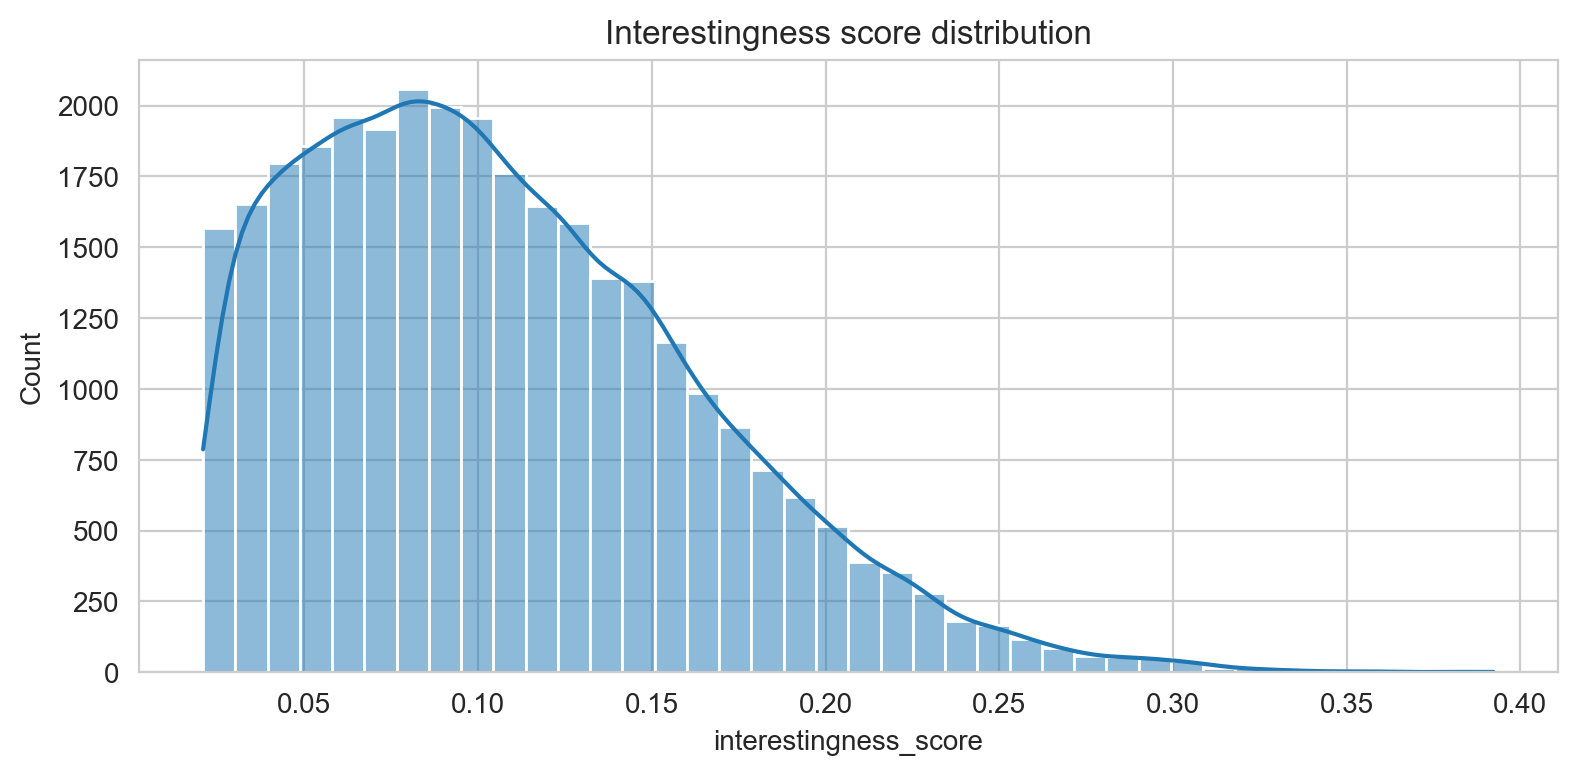

In [12]:
single_sentence__df, embeddings = run_nlp_quality_filter(
    single_sentence__df, device=str(device)
)
plot_interestingness_distribution(single_sentence__df)

## Token-count filter

Count explainability tokens (mask sum) and keep only entries with ≤ 12 tokens — slightly above the VoiceBench single-sentence cap of 10 to allow headroom after audio attachment.

**Last run:** 609 rows remain after this step (from 31,223 post–semantic-dedup candidates).

In [13]:
single_sentence__df, candidates = run_token_count_filter(
    single_sentence__df, model_for_tokens, max_token_count=12
)

token counting:   0%|          | 0/31223 [00:00<?, ?it/s]

Computed token counts for 31223 entries.
Candidates with token_count <= 12: 609


## Stratified sampling (target 1 000)

We sample jointly on `datasets__combined` × `token_count` via `sample_single_sentence_nk` to preserve source distribution and token-count diversity.

**Last run:** final size **609** — the token-filtered pool has only 609 rows, so the 1k target is not reached.

In [ ]:
candidates = prepare_candidates(candidates)

Final dataset size: 609


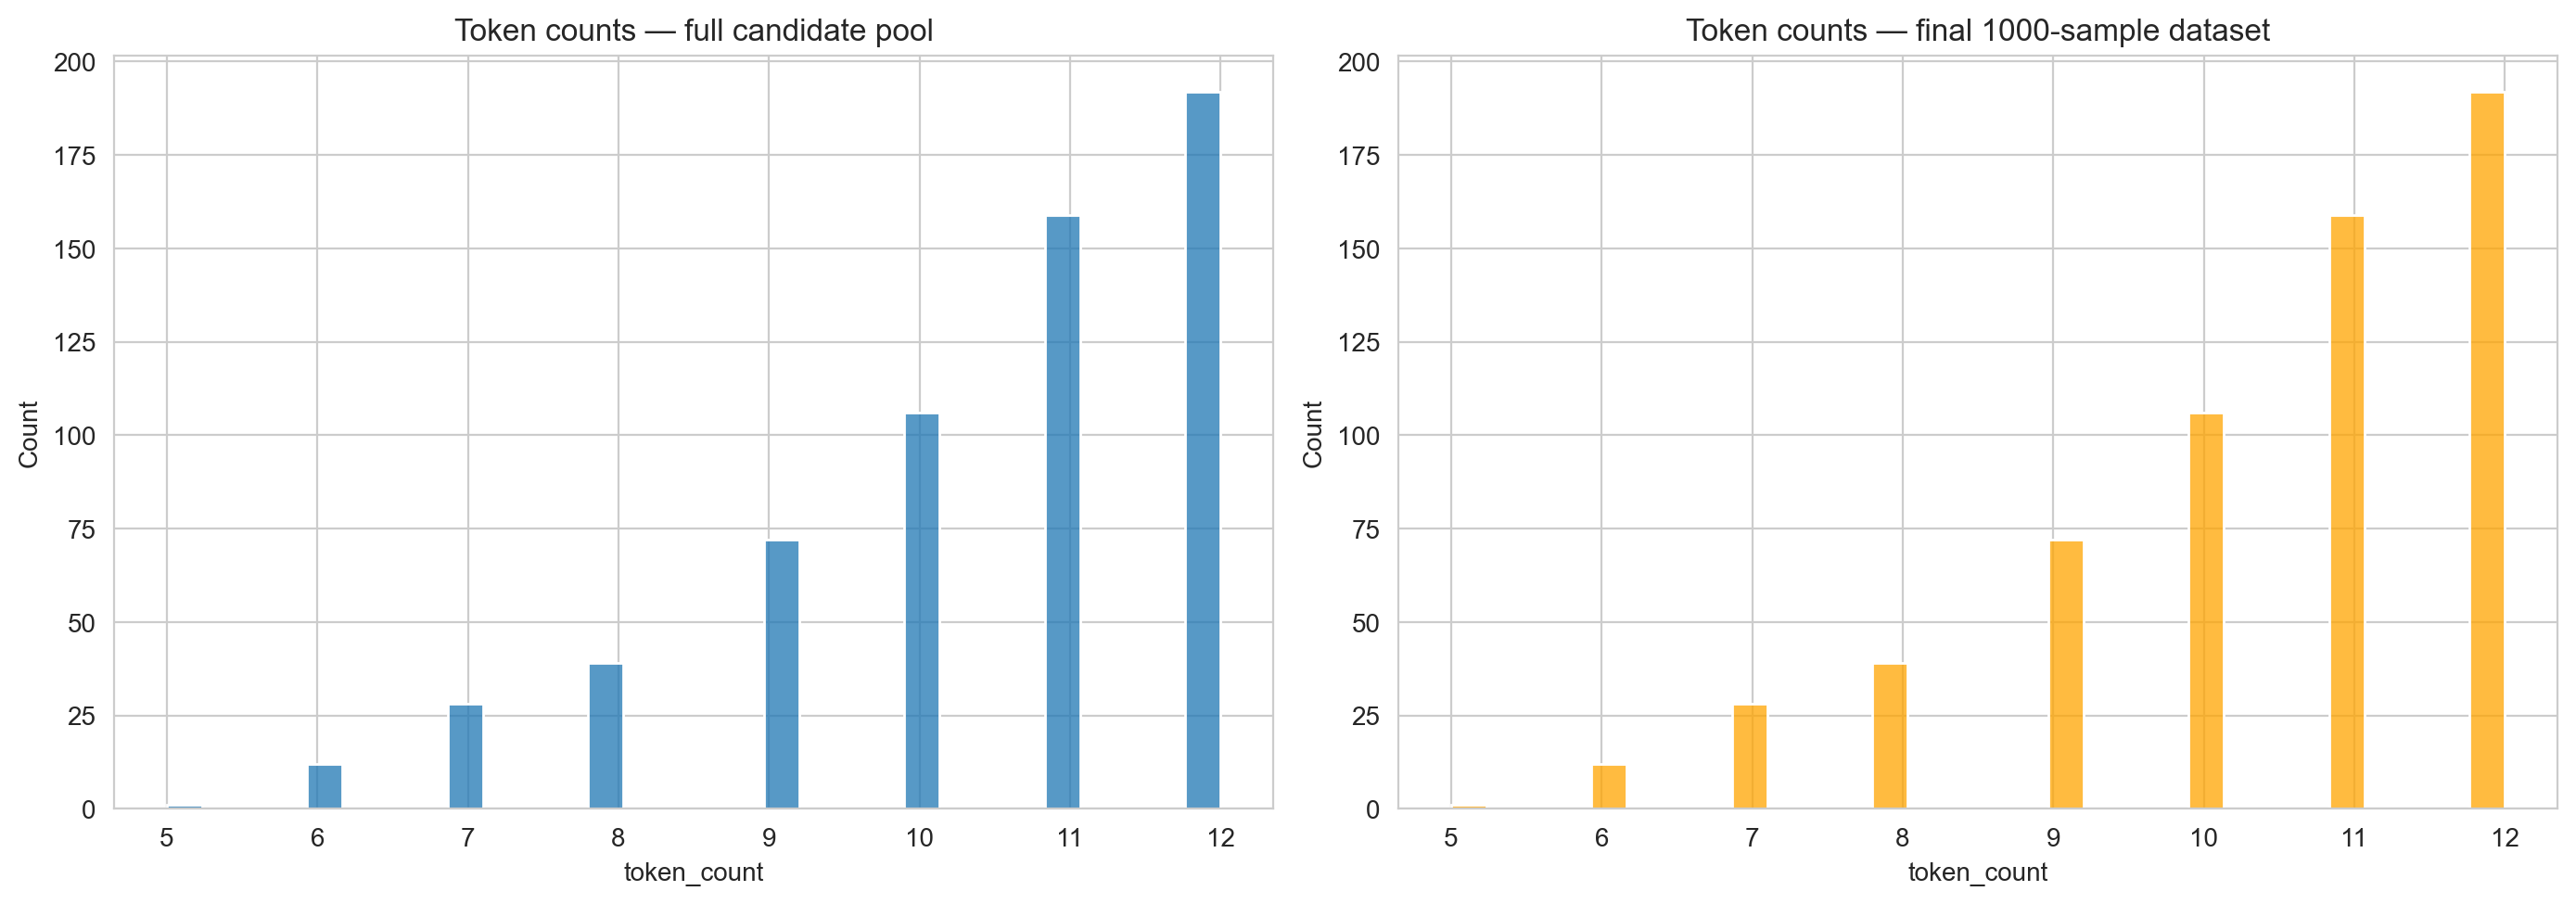

Token count summary (final):
count    609.000000
mean      10.420361
std        1.579259
min        5.000000
25%       10.000000
50%       11.000000
75%       12.000000
max       12.000000
Name: token_count, dtype: float64


In [15]:
single_sentence__df = sample_single_sentence_nk(
    candidates, n_target=HUB_TARGET_SAMPLES, plot_label=HUB_TARGET_SAMPLES
)

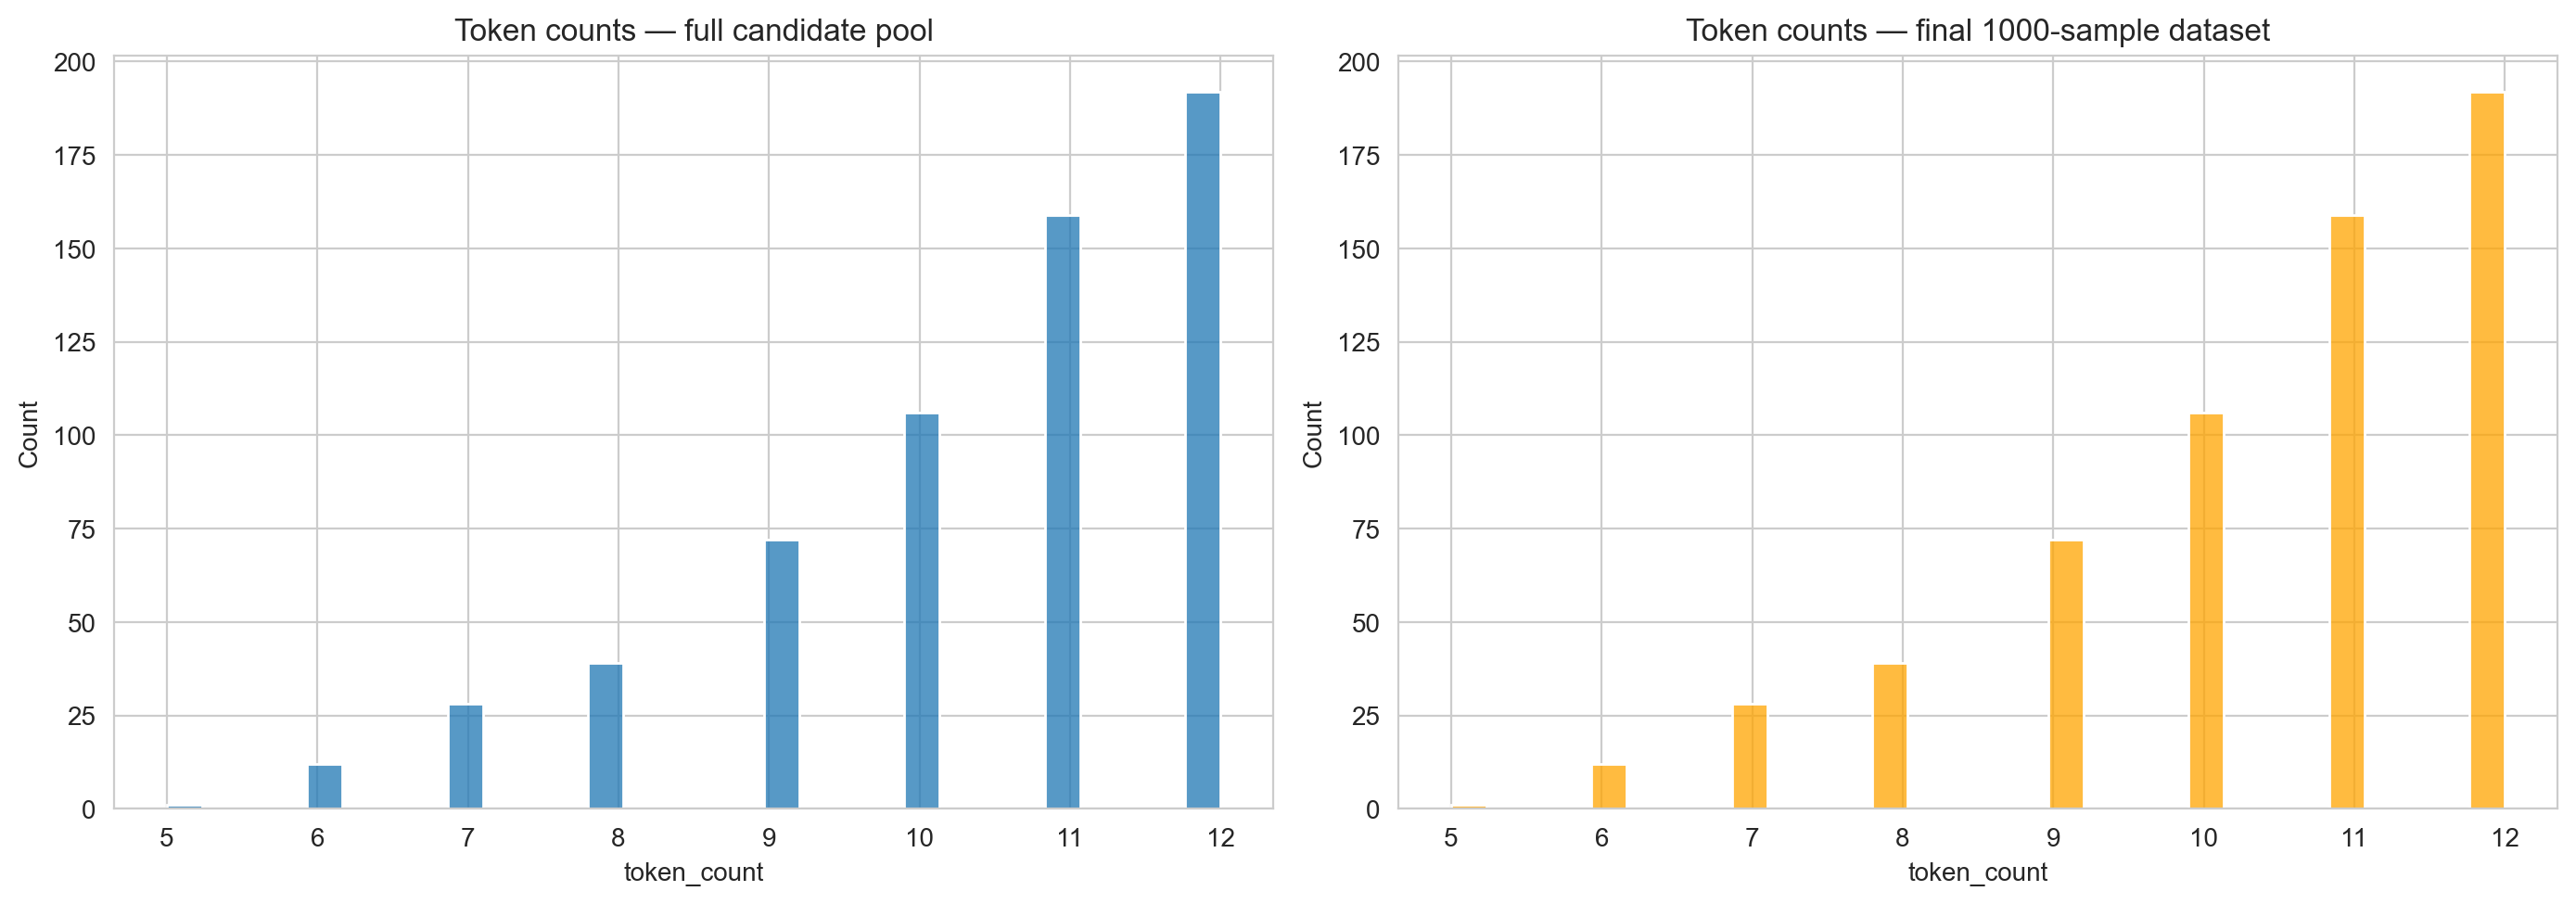

Token count summary (final):
count    609.000000
mean      10.420361
std        1.579259
min        5.000000
25%       10.000000
50%       11.000000
75%       12.000000
max       12.000000
Name: token_count, dtype: float64


In [16]:
plot_token_count_comparison(candidates, single_sentence__df, HUB_TARGET_SAMPLES)

In [17]:
single_sentence__df = attach_librispeech_audio(
    single_sentence__df, LIBRISPEECH_ASR__CONFIG
)

Skipping missing split: dev (candidates: ('dev', 'dev.clean'))
Attaching audio from clean/train.100/ (14 shards)
Attaching audio from clean/train.360/ (48 shards)


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/47 [00:00<?, ?it/s]

Attaching audio from clean/test/ (1 shards)
Attached audio for 609 / 609 sampled prompts


## Stats

### Dataset-level metrics

In [18]:
report_dataset_stats(single_sentence__df, include_audio=True)

{'audio__original__duration__average': 2.58,
 'audio__original__duration__total': 1574.17,
 'avg_characters__num': 26.53,
 'avg_sentences__num': 1.0,
 'characters__num': 16158,
 'min_sentences__num': 1,
 'rows__num': 609,
 'total_sentences__num': 609,
 'unique_entries__num': 609,
 'unique_entries__pct': 100.0}
{'2n^2': 135174,
 '3n^2': 201829,
 '4n^2': 267644,
 'frac 0.1': 127184.0,
 'frac 0.2': 254368.0,
 'n^2': 67644}


,datasets,num_rows,total_characters,avg_num_characters,avg_num_sentences,total_sentences
0,LibriSpeech-ASR-clean,609,16158,26.53202,1.0,609


In [19]:
pprint(compute_budgets(single_sentence__df["token_count"]))

{'2n^2': 135174,
 '3n^2': 201829,
 '4n^2': 267644,
 'frac 0.1': 127184.0,
 'frac 0.2': 254368.0,
 'n^2': 67644}


## Save dataset

The saved parquet contains `audio__original` (`list[bytes]`) and `audio__original__duration` (`list[float]`).

**Last run:** `single_sentence__librispeech_asr.parquet` — **609** rows; mean `token_count` ≈ 10.4 (max 12); mean clip duration ≈ 2.6 s.

In [20]:
save_single_sentence(
    single_sentence__df,
    LIBRISPEECH_ASR__CONFIG.data_dir,
    name=SINGLE_SENTENCE__LIBRISPEECH_ASR,
).head(3)

  0%|          | 0/609 [00:00<?, ?it/s]

Saved 609 rows to single_sentence__librispeech_asr.parquet


,datasets,sentences
0,LibriSpeech-ASR-clean,[A CONDITION MORE ABJECT THAN THAT]


### Processed samples

## Cleanup

In [21]:
del single_sentence__df, candidates, embeddings

# Final cleanup

In [22]:
shutil.rmtree(LIBRISPEECH_ASR__CONFIG.cache_dir)